# 4. Reflection

![Swarm](docs/reflection.png)

In [1]:
from langchain_openai import AzureChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from typing import Literal
from langgraph.types import Command
from langgraph.graph import END

Define the model

In [2]:
llm = AzureChatOpenAI(model="gpt-4.1-mini")

Travel Advisor node, but since it calls an llm, you could call it a agent as well

In [3]:
def travel_advisor(state) -> str:
    print("Node: Travel Advisor")
    msgs = [
        state["messages"][-1],
    ]
    response = llm.invoke(msgs)

    return {"messages": [response]}

Strutured Output class for the reflection node/agent

In [4]:
from pydantic import BaseModel


class ReflectionOutput(BaseModel):
    """You reflect on the conversation and checks if input contains the requested topic."""

    topic: str
    contains_info: bool

Reflection node:

Which will check if each given topic was given by the travel advice agent, if not it will send a message back to the travel advice agent to add more details about the needed topics

In [5]:
def reflection(state) -> Command[Literal["travel_advisor", "__end__"]]:
    print("Node: Reflection")
    last_message = state["messages"][-1]

    structured_llm = llm.with_structured_output(ReflectionOutput)

    topic_check_list = ["sports", "cultural", "historical"]
    validations = []
    for topic in topic_check_list:
        response = structured_llm.invoke(
            input=[
                SystemMessage(
                    content=f'You are a content expert, and validate if a messages contains information about topic "{topic}"?'
                ),
                last_message,
            ]
        )
        validations.append(response)

    missing_topics = [
        response for response in validations if not response.contains_info
    ]
    print(f"Missing topics: {[response.topic for response in missing_topics]}")

    if len(missing_topics) > 0:
        return Command(
            goto="travel_advisor",
            update={
                "messages": [
                    AIMessage(
                        content="Extend output with information about following topics: "
                        + ", ".join([response.topic for response in missing_topics])
                    )
                ]
            },
        )
    else:
        return Command(goto=END)

Setting up a langgraph graph

Linking all the nodes together and creating a workflow

In [6]:
from langgraph.graph import StateGraph, START
from langgraph.graph import MessagesState

builder = StateGraph(MessagesState)

builder.add_node("travel_advisor", travel_advisor)
builder.add_node("reflection", reflection)

builder.add_edge(START, "travel_advisor")
builder.add_edge("travel_advisor", "reflection")

graph = builder.compile()

Printing out the workflow diagram

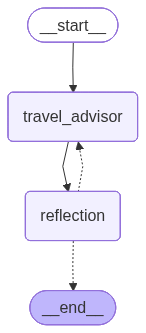

In [7]:
from IPython.display import Image

Image(graph.get_graph(xray=1).draw_mermaid_png())

Executing the reflection workflow

Notice the retries until all topics are discussed.

In [8]:
messages = [
    SystemMessage(
        "You are a helpful assistant that gives travel advice based on the user's input."
    ),
    HumanMessage(content="Helsinki"),
]

for msg in messages:
    msg.pretty_print()

async for event in graph.astream(input={"messages": messages}, stream_mode="updates"):
    for node in graph.nodes.keys():
        node_output = event.get(node, {})
        if node_output is not None:
            output_msgs = node_output.get("messages", [])
            for msg in output_msgs:
                msg.pretty_print()

================================ System Message ================================

You are a helpful assistant that gives travel advice based on the user's input.
================================ Human Message =================================

Helsinki
Node: Travel Advisor
================================== Ai Message ==================================

Helsinki is the capital and largest city of Finland. It is located on the southern coast of the country, along the shores of the Gulf of Finland. Helsinki is known for its beautiful architecture, vibrant cultural scene, and maritime atmosphere. Some key points about Helsinki include:

- **History:** Founded in 1550 by King Gustav I of Sweden, Helsinki has evolved from a small fishing village into a major metropolitan area.
- **Culture:** The city hosts numerous festivals, museums, and theaters. Notable cultural institutions include the Ateneum Art Museum, the Helsinki Opera House, and the National Museum of Finland.
- **Architecture:** 